In [ ]:
pip install meteostat

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 903.4 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.8/93.8 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 37.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.5/506.5 kB 22.4 MB/s eta 0:00:00
  Attempting uninstall: pytz
    Found existing installation: pytz 2025.2
    Uninstalling pytz-2025.2:
      Successfully uninstalled pytz-2025.2
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.2 which is incompatible.
gradio 5.50.0 requir

In [ ]:
import time
from bs4 import BeautifulSoup
import requests
from datetime import date, datetime, time as dtime, timedelta
import re
import numpy as np
import pandas as pd
from tqdm import tqdm
import meteostat as ms
import os
import warnings
import holidays

ms.config.block_large_requests = False
warnings.filterwarnings('ignore')

def get_wait_time_data(start_date, end_date, park_name, output_folder_path=None):

  wait_time_data = {}
  park_hours_data = {"date": [], "day_of_week": [], "open_time": [], "close_time": [], "ea_time": []}

  with tqdm(total=(end_date - start_date).days, desc=f"Scraping {park_name.replace("-", " ").title()} Wait Times...") as progress:
    while start_date <= end_date:

      response = requests.get(f"https://c.touringplans.com/{park_name}/wait-times/date/{start_date}")

      if response.status_code == 200:
        soup = BeautifulSoup(response.content, "html.parser")

        open_close_times = soup.find_all("td", class_="rating")

        if not open_close_times:
          start_date += timedelta(days=1)
          progress.update(1)
          continue

        open_time = datetime.strptime(open_close_times[0].get_text().removeprefix("\n\t\t\t\t\t").removesuffix("\n\t\t\t\t"), "%I:%M%p").time()
        close_time = datetime.strptime(open_close_times[1].get_text().removeprefix("\n\t\t\t\t\t").removesuffix("\n\t\t\t\t"), "%I:%M%p").time()

        # Get early admission time
        ea_time = soup.select_one("strong:has(span.light_purple)")
        if ea_time:
          ea_time = datetime.strptime(ea_time.get_text().removeprefix("\n\t\t\t\t\tEarly Park Admission\n\n\t\t\t\t\tat "), "%I:%M%p").time()

        day_of_week = start_date.weekday()

        park_hours_data["date"].append(start_date)
        park_hours_data["day_of_week"].append(day_of_week)
        park_hours_data["open_time"].append(open_time)
        park_hours_data["close_time"].append(close_time)
        park_hours_data["ea_time"].append(ea_time)

        # Get attraction wait times and names
        content = str(response.content)

        wait_time_pattern = r"new Date\(\s*(\d+)\s*,\s*(\d+)\s*,\s*(\d+)\s*,\s*(\d+)\s*,\s*(\d+)\s*,\s*(\d+)\s*\),{7}(\d+)"
        ride_name_pattern = r'title:\s*"([^"]+?)\s*-\s*\d+/\d+/\d+"'

        combined_regex = re.compile(f"(?P<wait_time>{wait_time_pattern})|(?P<ride_name>{ride_name_pattern})")

        temp_stats = []

        for match in combined_regex.finditer(content):
            if match.lastgroup == "wait_time":
                stat_values = [int(x) for x in match.groups()[1:8]]
                ride_date = date(stat_values[0], stat_values[1] + 1, stat_values[2])
                ride_time = dtime(stat_values[3], stat_values[4], stat_values[5])
                temp_stats.append([ride_date, start_date, ride_time, int(stat_values[6])])

            elif match.lastgroup == "ride_name":
                ride_name = match.group(10).strip().lower()
                ride_name = re.sub(r'[^a-z ]', '', ride_name).replace("  ", "-").replace(" ", "-")

                if ride_name not in wait_time_data.keys():
                  wait_time_data[ride_name] = pd.DataFrame(temp_stats, columns=["date", "start_date", "time", "wait_time"])
                elif temp_stats:
                  wait_time_data[ride_name] = pd.concat([wait_time_data[ride_name], pd.DataFrame(temp_stats, columns=["date", "start_date", "time", "wait_time"])], ignore_index=True)

                temp_stats = []
      else:
        print(response.status_code)
        time.sleep(5)

      start_date += timedelta(days=1)
      progress.update(1)

  progress.close()

  park_hours_data = pd.DataFrame(park_hours_data)

  # Save dataframes to CSV
  if output_folder_path:
    print(f"\nSaving {park_name.replace("-", " ").title()} Wait Time Data...\n")
    for key in wait_time_data.keys():
      wait_time_data[key].to_csv(f"{output_folder_path}Wait_Times/{key}.csv", index=False)
    print(f"\nSaving {park_name.replace("-", " ").title()} Hours Data...\n")
    park_hours_data.to_csv(f"{output_folder_path}{park_name}_hours.csv", index=False)
  else:
    return wait_time_data, park_hours_data

def get_showtime_data(start_date, end_date, park_name, output_folder_path=None):

  showtime_data = {"date": [], "land": [], "show_name": [], "showtime": []}

  with tqdm(total=(end_date - start_date).days, desc=f"Scraping {park_name.replace("-", " ").title()} Showtimes...") as progress:
    while start_date <= end_date:

      response = requests.get(f"https://c.touringplans.com/{park_name}/showtimes/date/{start_date}")
      soup = BeautifulSoup(response.content, "html.parser")

      # Get show info and showtimes
      for div in soup.find_all("div", class_="showtimes"):
        land = div.find_previous_sibling("h3")
        if land:
          show_name = ""
          for strong in div.find_all("strong"):
            if strong.find("a"):
              show_name = strong.get_text()
            else:
              showtime_data["date"].append(start_date)
              showtime_data["land"].append(land.get_text())
              showtime_data["show_name"].append(show_name)
              showtime_data["showtime"].append(datetime.strptime(re.sub(r'\s+', '', strong.get_text()), "%I:%M%p").time())

      start_date += timedelta(days=1)
      progress.update(1)

  progress.close()

  # Save dataframes to CSV
  if output_folder_path:
    print(f"\nSaving {park_name.replace("-", " ").title()} Showtime Data...\n")
    pd.DataFrame(showtime_data).to_csv(f"{output_folder_path}{park_name}_showtimes.csv", index=False)
  else:
    return pd.DataFrame(showtime_data)

def get_weather_data(start_date, end_date, weather_station_id, output_folder_path):
  hourly_weather = ms.hourly(weather_station_id, start_date, end_date).fetch(units=ms.UnitSystem.IMPERIAL).reset_index().drop(columns=["snwd", "wpgt", "tsun"])

  hourly_weather["date"] = hourly_weather["time"].apply(lambda x : x.date())
  hourly_weather["hour"] = hourly_weather["time"].apply(lambda x : x.time())
  hourly_weather.drop(columns=["time"], inplace=True)

  hourly_weather["temp"] = (hourly_weather["temp"].ffill() + hourly_weather["temp"].bfill()) / 2
  hourly_weather["rhum"] = (hourly_weather["rhum"].ffill() + hourly_weather["rhum"].bfill()) / 2
  hourly_weather["prcp"] = (hourly_weather["prcp"].ffill() + hourly_weather["prcp"].bfill()) / 2
  hourly_weather["prcp"] = hourly_weather["prcp"].fillna(0)
  hourly_weather["wdir"] = (hourly_weather["wdir"].ffill() + hourly_weather["wdir"].bfill()) / 2
  hourly_weather["pres"] = (hourly_weather["pres"].ffill() + hourly_weather["pres"].bfill()) / 2
  hourly_weather["cldc"] = (hourly_weather["cldc"].ffill() + hourly_weather["cldc"].bfill()) / 2
  hourly_weather["coco"] = ((hourly_weather["coco"].ffill().bfill() + hourly_weather["coco"].bfill()) // 2).astype("int64")

  hourly_weather.to_csv(f"{output_folder_path}orlando_hourly_weather_data.csv", index=False)

def get_baseline_prediction_data(start_date, end_date, park_name, output_folder_path=None):
  wait_time_data = {}

  with tqdm(total=(end_date - start_date).days, desc=f"Scraping {park_name.replace("-", " ").title()} Predicted Wait Times...") as progress:
    while start_date <= end_date:

      response = requests.get(f"https://c.touringplans.com/{park_name}/wait-times/date/{start_date}")

      if response.status_code == 200:
        soup = BeautifulSoup(response.content, "html.parser")

        open_close_times = soup.find_all("td", class_="rating")

        if not open_close_times:
          start_date += timedelta(days=1)
          progress.update(1)
          continue

        content = str(response.content)

        wait_time_pattern = r"new Date\(\s*(\d+)\s*,\s*(\d+)\s*,\s*(\d+)\s*,\s*(\d+)\s*,\s*(\d+)\s*,\s*(\d+)\s*\),{4}(\d+)"
        ride_name_pattern = r'title:\s*"([^"]+?)\s*-\s*\d+/\d+/\d+"'

        combined_regex = re.compile(f"(?P<wait_time>{wait_time_pattern})|(?P<ride_name>{ride_name_pattern})")

        temp_stats = []

        for match in combined_regex.finditer(content):
            if match.lastgroup == "wait_time":
                stat_values = [int(x) for x in match.groups()[1:8]]
                ride_date = date(stat_values[0], stat_values[1] + 1, stat_values[2])
                ride_time = dtime(stat_values[3], stat_values[4], stat_values[5])
                temp_stats.append([ride_date, ride_time, int(stat_values[6])])

            elif match.lastgroup == "ride_name":
                ride_name = match.group(10).strip().lower()
                ride_name = re.sub(r'[^a-z ]', '', ride_name).replace("  ", "-").replace(" ", "-")

                if ride_name not in wait_time_data.keys():
                  wait_time_data[ride_name] = pd.DataFrame(temp_stats, columns=["date", "time", "wait_time"])
                elif temp_stats:
                  wait_time_data[ride_name] = pd.concat([wait_time_data[ride_name], pd.DataFrame(temp_stats, columns=["date", "time", "wait_time"])], ignore_index=True)

                temp_stats = []
      else:
        print(response.status_code)
        time.sleep(5)

      start_date += timedelta(days=1)
      progress.update(1)

  progress.close()

  # Save dataframes to CSV
  if output_folder_path:
    print(f"\nSaving {park_name.replace("-", " ").title()} Predicted Wait Time Data...\n")
    for key in wait_time_data.keys():
      wait_time_data[key].to_csv(f"{output_folder_path}Baseline_Predictions/{key}.csv", index=False)
  else:
    return wait_time_data


In [ ]:
# Universal Island's of Adventure Wait Times
#get_wait_time_data(date(2016, 1, 1), date(2025, 12, 31), "islands-of-adventure", "/content/drive/MyDrive/Theme_Park_Data/Universal_IOA/")

# Universal Studios Florida Wait Times
#get_wait_time_data(date(2016, 1, 1), date(2025, 12, 31), "universal-studios-florida", "/content/drive/MyDrive/Theme_Park_Data/Universal_Studios_FL/")

# Universal Island's of Adventure Showtimes
#get_showtime_data(date(2016, 1, 1), date(2025, 12, 31), "islands-of-adventure", "/content/drive/MyDrive/Theme_Park_Data/Universal_IOA/")

# Universal Studios Florida Showtimes
#get_showtime_data(date(2016, 1, 1), date(2025, 12, 31), "universal-studios-florida", "/content/drive/MyDrive/Theme_Park_Data/Universal_Studios_FL/")

# Orlando Weather
#get_weather_data(date(2016, 1, 1), date(2025, 12, 31), "72205", "/content/drive/MyDrive/Theme_Park_Data/")

# Universal Islands of Adventure Baseline Predictions
#get_baseline_prediction_data(date(2025, 1, 1), date(2025, 12, 31), "islands-of-adventure", "/content/drive/MyDrive/Theme_Park_Data/Universal_IOA/")

# Universal Studios Florida Baseline Predictions
get_baseline_prediction_data(date(2025, 1, 1), date(2025, 12, 31), "universal-studios-florida", "/content/drive/MyDrive/Theme_Park_Data/Universal_Studios_FL/")

Scraping Universal Studios Florida Predicted Wait Times...: 365it [09:25,  1.55s/it]



Saving Universal Studios Florida Predicted Wait Time Data...



<Axes: >

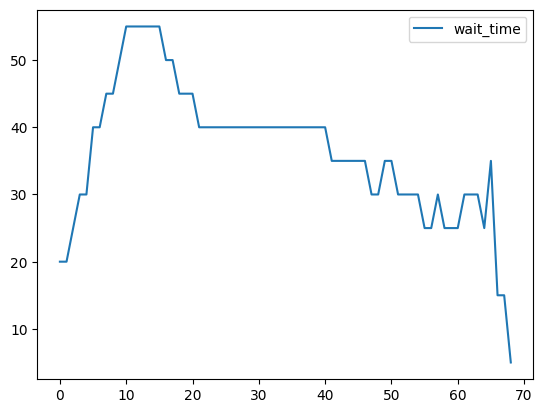

In [ ]:
p["despicable-me-minion-mayhem"].plot()